In [26]:
# Cell 1 — Title & Overview
# ============================================================
# 04_risk_intelligence.ipynb
# Olist Supply Chain Risk Intelligence
# ============================================================
# This notebook:
# 1. Seller reliability scoring
# 2. SLA breach categorization
# 3. Route risk analysis
# 4. Revenue at risk priority scoring
# 5. Delay intervention recommendations
# 6. Demand concentration risk
# 7. All charts saved to data/charts/
# Prerequisites: 03_ml_models.ipynb must be run first
# ============================================================

In [27]:
# Cell 2 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas_gbq
from google.oauth2 import service_account
from google.cloud import bigquery
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

print("Libraries loaded ✅")

Libraries loaded ✅


In [28]:
# Cell 3 — Configuration
KEY_PATH   = "bq_key.json"

PROJECT_ID = "supply-chain-analytics-500607"
DATASET_ID = "olist"
TABLE      = f"`{PROJECT_ID}.{DATASET_ID}.orders_master`"

credentials = service_account.Credentials.from_service_account_file(
    KEY_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

os.makedirs("../data/charts", exist_ok=True)

def run_query(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

def save_to_bq(df: pd.DataFrame, table_name: str) -> None:
    pandas_gbq.to_gbq(
        df,
        destination_table=f"{DATASET_ID}.{table_name}",
        project_id=PROJECT_ID,
        credentials=credentials,
        if_exists="replace",
        progress_bar=False,
    )
    print(f"  ✅ BigQuery: {DATASET_ID}.{table_name}")

def save_chart(filename: str) -> None:
    path = f"../data/charts/{filename}"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Chart saved: {filename}")

print(f"Connected to: {PROJECT_ID}.{DATASET_ID} ✅")

Connected to: supply-chain-analytics-500607.olist ✅


In [29]:
# Cell 4 — Reload trained classifier from 03_ml_models
# We need xgb_clf to generate late_probability scores
# Run this cell to rebuild the model quickly

FEATURES = [
    "total_payment_value", "payment_installments", "payment_type",
    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm",
    "category", "seller_state", "customer_state",
    "order_month", "order_dayofweek",
    "seller_late_rate", "seller_avg_delay", "seller_total_orders",
    "route_late_rate",  "route_avg_delay",  "route_total_orders",
]

ml_final = run_query(f"""
    SELECT
        m.order_id,
        m.delivery_delay_days,
        m.is_late,
        CAST(m.total_payment_value   AS FLOAT64) AS total_payment_value,
        CAST(m.payment_installments  AS FLOAT64) AS payment_installments,
        m.payment_type,
        CAST(m.product_weight_g      AS FLOAT64) AS product_weight_g,
        CAST(m.product_length_cm     AS FLOAT64) AS product_length_cm,
        CAST(m.product_height_cm     AS FLOAT64) AS product_height_cm,
        CAST(m.product_width_cm      AS FLOAT64) AS product_width_cm,
        m.product_category_name_english          AS category,
        m.seller_state,
        m.customer_state,
        CAST(EXTRACT(MONTH     FROM m.order_purchase_timestamp) AS FLOAT64) AS order_month,
        CAST(EXTRACT(DAYOFWEEK FROM m.order_purchase_timestamp) AS FLOAT64) AS order_dayofweek,
        CAST(COALESCE(s.seller_late_rate,    0) AS FLOAT64) AS seller_late_rate,
        CAST(COALESCE(s.seller_avg_delay,    0) AS FLOAT64) AS seller_avg_delay,
        CAST(COALESCE(s.seller_total_orders, 0) AS FLOAT64) AS seller_total_orders,
        CAST(COALESCE(r.route_late_rate,     0) AS FLOAT64) AS route_late_rate,
        CAST(COALESCE(r.route_avg_delay,     0) AS FLOAT64) AS route_avg_delay,
        CAST(COALESCE(r.route_total_orders,  0) AS FLOAT64) AS route_total_orders
    FROM `{PROJECT_ID}.{DATASET_ID}.orders_master` m
    LEFT JOIN `{PROJECT_ID}.{DATASET_ID}.seller_stats` s USING (seller_id)
    LEFT JOIN `{PROJECT_ID}.{DATASET_ID}.route_stats` r
        ON  m.seller_state   = r.seller_state
        AND m.customer_state = r.customer_state
    WHERE m.delivery_delay_days IS NOT NULL
      AND m.product_weight_g    IS NOT NULL
""")

df_model = ml_final.copy()
for col in ["seller_state", "customer_state", "payment_type", "category"]:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model[FEATURES] = df_model[FEATURES].apply(
    pd.to_numeric, errors="coerce"
).fillna(0).astype(float)

X     = df_model[FEATURES]
y_clf = df_model["is_late"]

class_ratio = int((y_clf == 0).sum() / (y_clf == 1).sum())

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=class_ratio, random_state=42, n_jobs=-1,
)
xgb_clf.fit(X, y_clf)
print(f"Classifier retrained on full dataset ✅")
print(f"Dataset shape: {X.shape}")

Classifier retrained on full dataset ✅
Dataset shape: (110189, 18)


In [30]:
# Cell 5 — Seller reliability scoring
seller_scorecard = run_query(f"""
    SELECT
        seller_id,
        seller_state,
        COUNT(DISTINCT order_id)            AS total_orders,
        ROUND(AVG(is_late) * 100, 2)        AS late_rate,
        ROUND(AVG(delivery_delay_days), 2)  AS avg_delay_days,
        ROUND(AVG(review_score), 2)         AS avg_review_score,
        ROUND(SUM(revenue_at_risk), 2)      AS total_revenue_at_risk,
        COUNTIF(order_status = 'canceled')  AS canceled_orders
    FROM {TABLE}
    WHERE seller_id IS NOT NULL
    GROUP BY seller_id, seller_state
    HAVING total_orders >= 10
    ORDER BY late_rate DESC
""")

def compute_reliability_score(row):
    late_penalty   = row["late_rate"] * 0.5
    delay_penalty  = min(row["avg_delay_days"] * 2, 30)
    cancel_penalty = min(row["canceled_orders"] * 2, 20)
    return round(max(100 - late_penalty - delay_penalty - cancel_penalty, 0), 2)

def reliability_tier(score):
    if score >= 80: return "Reliable"
    if score >= 60: return "Watchlist"
    return "High Risk"

seller_scorecard["reliability_score"] = seller_scorecard.apply(
    compute_reliability_score, axis=1
)
seller_scorecard["reliability_tier"] = seller_scorecard["reliability_score"].apply(
    reliability_tier
)

print(f"Sellers scored: {len(seller_scorecard):,}")
print(f"\nTier distribution:")
print(seller_scorecard["reliability_tier"].value_counts().to_string())

seller_scorecard.to_csv("../data/seller_scorecard.csv", index=False)
save_to_bq(seller_scorecard, "seller_scorecard")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Sellers scored: 1,237

Tier distribution:
reliability_tier
Reliable     1235
High Risk       1
Watchlist       1
  ✅ BigQuery: olist.seller_scorecard


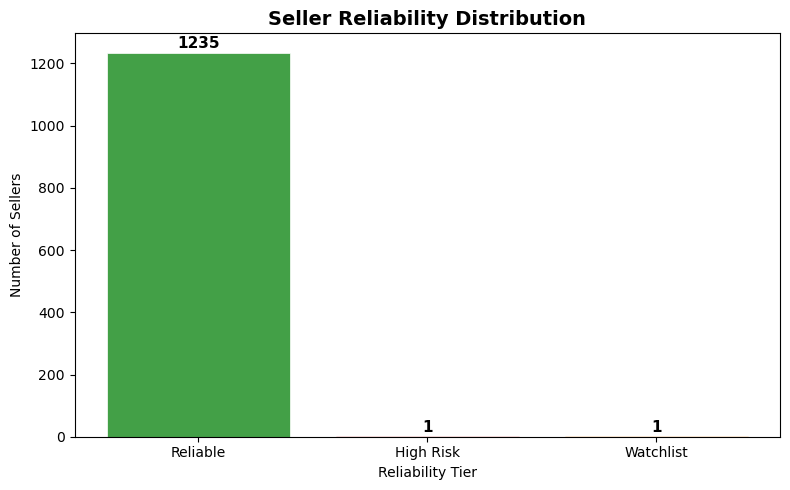

  ✅ Chart saved: 04_seller_reliability.png


In [31]:
# Cell 6 — Chart 1: Seller reliability distribution
tier_counts = seller_scorecard["reliability_tier"].value_counts()
colors = {"Reliable": "#43A047", "Watchlist": "#FB8C00", "High Risk": "#E53935"}

plt.figure(figsize=(8, 5))
bars = plt.bar(
    tier_counts.index,
    tier_counts.values,
    color=[colors[t] for t in tier_counts.index],
    edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars, tier_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("Seller Reliability Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Reliability Tier")
plt.ylabel("Number of Sellers")
plt.tight_layout()
save_chart("04_seller_reliability.png")

In [ ]:
# Cell 7 — SLA breach categorization
sla_analysis = run_query(f"""
    SELECT
        order_id,
        delivery_delay_days,
        total_payment_value,
        seller_state,
        customer_state,
        product_category_name_english AS category,
        order_month,
        CASE
            WHEN delivery_delay_days < -3  THEN 'Early (3+ days)'
            WHEN delivery_delay_days <= 0  THEN 'On Time'
            WHEN delivery_delay_days <= 3  THEN '1-3 Days Late'
            WHEN delivery_delay_days <= 7  THEN '4-7 Days Late'
            ELSE '8+ Days Late'
        END AS sla_category,
        CASE
            WHEN delivery_delay_days < -3  THEN 1
            WHEN delivery_delay_days <= 0  THEN 2
            WHEN delivery_delay_days <= 3  THEN 3
            WHEN delivery_delay_days <= 7  THEN 4
            ELSE 5
        END AS sla_severity
    FROM {TABLE}
    WHERE delivery_delay_days IS NOT NULL
""")

sla_summary = (
    sla_analysis
    .groupby(["sla_category", "sla_severity"])
    .agg(
        order_count   = ("order_id",           "count"),
        total_revenue = ("total_payment_value", "sum"),
        avg_delay     = ("delivery_delay_days", "mean"),
    )
    .reset_index()
    .sort_values("sla_severity")
)
sla_summary["order_pct"] = (
    sla_summary["order_count"] / sla_summary["order_count"].sum() * 100
).round(2)

print(sla_summary[["sla_category", "order_count", "order_pct", "avg_delay"]].to_string())
sla_analysis.to_csv("../data/sla_analysis.csv", index=False)
sla_summary.to_csv("../data/sla_summary.csv", index=False)
save_to_bq(sla_analysis, "sla_analysis")
save_to_bq(sla_summary,  "sla_summary")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


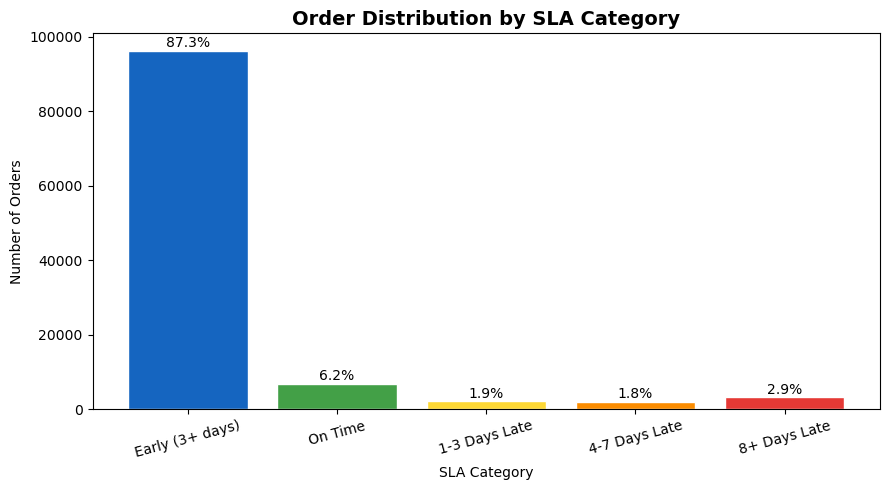

  ✅ Chart saved: 01_sla_distribution.png


In [ ]:
# Cell 8 — Chart 2: SLA distribution
sla_order = ["Early (3+ days)", "On Time", "1-3 Days Late", "4-7 Days Late", "8+ Days Late"]
sla_colors = ["#1565C0", "#43A047", "#FDD835", "#FB8C00", "#E53935"]

sla_plot = sla_summary.set_index("sla_category").reindex(sla_order)

plt.figure(figsize=(9, 5))
bars = plt.bar(
    sla_plot.index,
    sla_plot["order_count"],
    color=sla_colors, edgecolor="white"
)
for bar, pct in zip(bars, sla_plot["order_pct"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f"{pct:.1f}%", ha="center", va="bottom", fontsize=10
    )
plt.title("Order Distribution by SLA Category", fontsize=14, fontweight="bold")
plt.xlabel("SLA Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=15)
plt.tight_layout()
save_chart("01_sla_distribution.png")

In [ ]:
# Cell 9 — Route risk analysis
route_risk = run_query(f"""
    SELECT
        seller_state,
        customer_state,
        CONCAT(seller_state, ' → ', customer_state) AS route,
        COUNT(DISTINCT order_id)                    AS order_count,
        ROUND(AVG(delivery_delay_days), 2)          AS avg_delay_days,
        ROUND(AVG(is_late) * 100, 2)               AS late_pct,
        ROUND(SUM(revenue_at_risk), 2)              AS revenue_at_risk,
        ROUND(AVG(total_payment_value), 2)          AS avg_order_value
    FROM {TABLE}
    WHERE seller_state        IS NOT NULL
      AND customer_state      IS NOT NULL
      AND delivery_delay_days IS NOT NULL
    GROUP BY seller_state, customer_state
    HAVING order_count >= 50
    ORDER BY late_pct DESC
""")

def route_risk_tier(row):
    if row["late_pct"] >= 30: return "Critical"
    if row["late_pct"] >= 20: return "High"
    if row["late_pct"] >= 10: return "Medium"
    return "Low"

route_risk["risk_tier"] = route_risk.apply(route_risk_tier, axis=1)

print(f"Routes analyzed : {len(route_risk):,}")
print(f"\nRisk distribution:")
print(route_risk["risk_tier"].value_counts().to_string())
print(f"\nTop 10 riskiest routes:")
print(route_risk.head(10)[
    ["route", "order_count", "late_pct", "avg_delay_days", "revenue_at_risk", "risk_tier"]
].to_string())

route_risk.to_csv("../data/route_risk.csv", index=False)
save_to_bq(route_risk, "route_risk")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Routes analyzed : 100

Risk distribution:
risk_tier
Low       76
Medium    21
High       3

Top 10 riskiest routes:
     route  order_count  late_pct  avg_delay_days  revenue_at_risk risk_tier
0  RJ → CE           54     23.21           -5.12          3016.75      High
1  SP → AL          256     22.71           -8.24         10944.22      High
2  MA → SP          124     21.54           -9.56          4327.69      High
3  SP → MA          493     19.67           -9.55         27306.45    Medium
4  SP → SE          208     18.14           -9.38         11387.28    Medium
5  MG → MA           64     16.42          -10.72          7797.63    Medium
6  SP → PI          329     16.30          -10.65         12020.56    Medium
7  MG → PA           84     15.22          -10.60          7414.58    Medium
8  SP → CE          970     13.66          -11.18         34071.49    Medium
9  PR → BA          144     13.50          -10.30          5694.76    Medium
  ✅ BigQuery: olist.route_risk


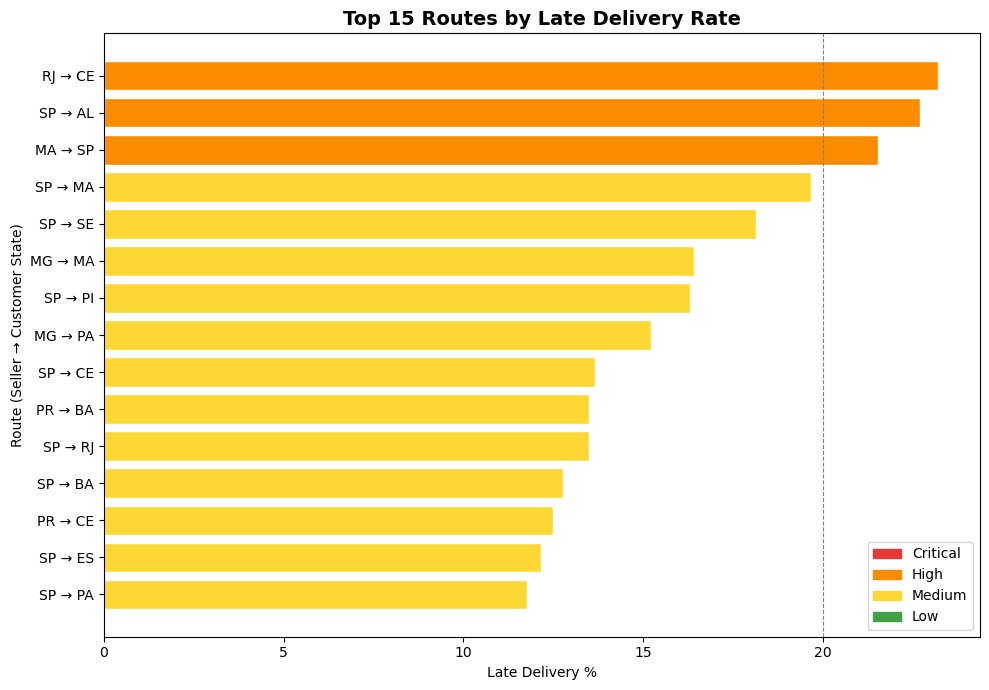

  ✅ Chart saved: 03_top_routes.png


In [ ]:
# Cell 10 — Chart 3: Top 15 high risk routes
top_routes = route_risk.head(15)
tier_colors = {"Critical": "#E53935", "High": "#FB8C00", "Medium": "#FDD835", "Low": "#43A047"}

plt.figure(figsize=(10, 7))
bars = plt.barh(
    top_routes["route"][::-1],
    top_routes["late_pct"][::-1],
    color=[tier_colors[t] for t in top_routes["risk_tier"][::-1]],
    edgecolor="white"
)
plt.axvline(x=20, color="gray", linestyle="--", linewidth=0.8, label="High Risk threshold (20%)")
plt.title("Top 15 Routes by Late Delivery Rate", fontsize=14, fontweight="bold")
plt.xlabel("Late Delivery %")
plt.ylabel("Route (Seller → Customer State)")

patches = [mpatches.Patch(color=c, label=l) for l, c in tier_colors.items()]
plt.legend(handles=patches, loc="lower right")
plt.tight_layout()
save_chart("03_top_routes.png")

In [ ]:
# Cell 11 — Revenue at risk priority scoring
priority_df = ml_final[["order_id", "total_payment_value",
                          "delivery_delay_days", "is_late"]].copy()

late_probs = xgb_clf.predict_proba(X)[:, 1]
priority_df["late_probability"] = late_probs.round(4)
priority_df["priority_score"]   = (
    priority_df["late_probability"] * priority_df["total_payment_value"]
).round(2)

def recommend_action(row):
    if row["late_probability"] > 0.7 and row["total_payment_value"] > 200:
        return "Priority carrier escalation"
    if row["late_probability"] > 0.5 and row["total_payment_value"] > 100:
        return "Proactive customer update"
    if row["late_probability"] > 0.3:
        return "Standard monitoring"
    return "No action needed"

priority_df["recommended_action"] = priority_df.apply(recommend_action, axis=1)

print("Intervention distribution:")
print(priority_df["recommended_action"].value_counts().to_string())
print(f"\nTop 10 priority orders:")
print(priority_df.nlargest(10, "priority_score")[
    ["order_id", "total_payment_value", "late_probability",
     "priority_score", "recommended_action"]
].to_string())

priority_df.to_csv("../data/priority_orders.csv", index=False)
save_to_bq(priority_df, "priority_orders")

Intervention distribution:
recommended_action
No action needed               56262
Standard monitoring            39003
Proactive customer update      12491
Priority carrier escalation     2433

Top 10 priority orders:
                               order_id  total_payment_value  late_probability  priority_score           recommended_action
98422  0812eb902a67711a1cb742b3cdaa65ae              6929.31            0.6943         4811.02    Proactive customer update
59293  fefacc66af859508bf1a7934eab1e97f              6922.21            0.6119         4235.70    Proactive customer update
20623  d3f66901a6743e15f9311547cc623b91              3792.59            0.7352         2788.31  Priority carrier escalation
47661  d7a2c0c1ff66b314f3bf166fb4157fd4              3184.55            0.8608         2741.26  Priority carrier escalation
78823  03caa2c082116e1d31e67e9ae3700499             13664.08            0.1789         2444.50             No action needed
78824  03caa2c082116e1d31e67e9ae37004

In [ ]:
# Cell 12 — Demand concentration risk
demand_concentration = run_query(f"""
    SELECT
        product_category_name_english                       AS category,
        COUNT(DISTINCT order_id)                            AS order_volume,
        COUNT(DISTINCT seller_id)                           AS seller_count,
        ROUND(AVG(total_payment_value), 2)                  AS avg_order_value,
        ROUND(COUNT(DISTINCT order_id) /
              (COUNT(DISTINCT seller_id) + 1), 2)           AS demand_per_seller,
        ROUND(
            COUNT(DISTINCT order_id) *
            AVG(total_payment_value) /
            (COUNT(DISTINCT seller_id) + 1), 2
        )                                                   AS demand_concentration_score
    FROM {TABLE}
    WHERE product_category_name_english IS NOT NULL
      AND product_category_name_english != 'unknown'
    GROUP BY category
    HAVING order_volume >= 50
    ORDER BY demand_concentration_score DESC
    LIMIT 30
""")

def concentration_tier(score):
    if score >= 50000: return "Critical"
    if score >= 20000: return "High"
    if score >= 5000:  return "Medium"
    return "Low"

demand_concentration["risk_label"] = demand_concentration[
    "demand_concentration_score"
].apply(concentration_tier)

print(f"Categories analyzed: {len(demand_concentration)}")
print(f"\nRisk distribution:")
print(demand_concentration["risk_label"].value_counts().to_string())
print(f"\nTop 10:")
print(demand_concentration.head(10).to_string())

demand_concentration.to_csv("../data/demand_concentration.csv", index=False)
save_to_bq(demand_concentration, "demand_concentration")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Categories analyzed: 30

Risk distribution:
risk_label
Low       26
Medium     3
High       1

Top 10:
                                category  order_volume  seller_count  avg_order_value  demand_per_seller  demand_concentration_score risk_label
0                              computers           177             9          1380.26              17.70                    24430.61       High
1                       office_furniture          1254            30           381.37              40.45                    15427.02     Medium
2                          watches_gifts          5493            95           236.82              57.22                    13550.46     Medium
3                         bed_bath_table          9272           189           154.54              48.80                     7541.72     Medium
4                  computers_accessories          6529           279           202.70              23.32                     4726.58        Low
5                           home_

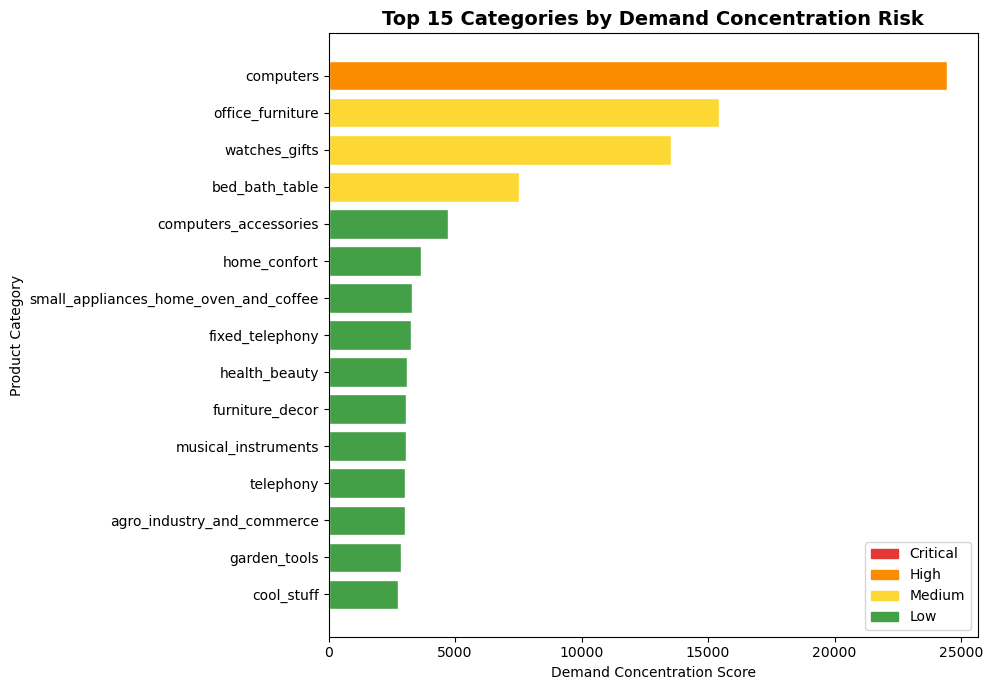

  ✅ Chart saved: 08_demand_concentration.png


In [ ]:
# Cell 13 — Chart 4: Demand concentration top 15
top_dc = demand_concentration.head(15)
dc_colors = {"Critical": "#E53935", "High": "#FB8C00", "Medium": "#FDD835", "Low": "#43A047"}

plt.figure(figsize=(10, 7))
plt.barh(
    top_dc["category"][::-1],
    top_dc["demand_concentration_score"][::-1],
    color=[dc_colors[r] for r in top_dc["risk_label"][::-1]],
    edgecolor="white"
)
plt.title("Top 15 Categories by Demand Concentration Risk", fontsize=14, fontweight="bold")
plt.xlabel("Demand Concentration Score")
plt.ylabel("Product Category")

patches = [mpatches.Patch(color=c, label=l) for l, c in dc_colors.items()]
plt.legend(handles=patches, loc="lower right")
plt.tight_layout()
save_chart("08_demand_concentration.png")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


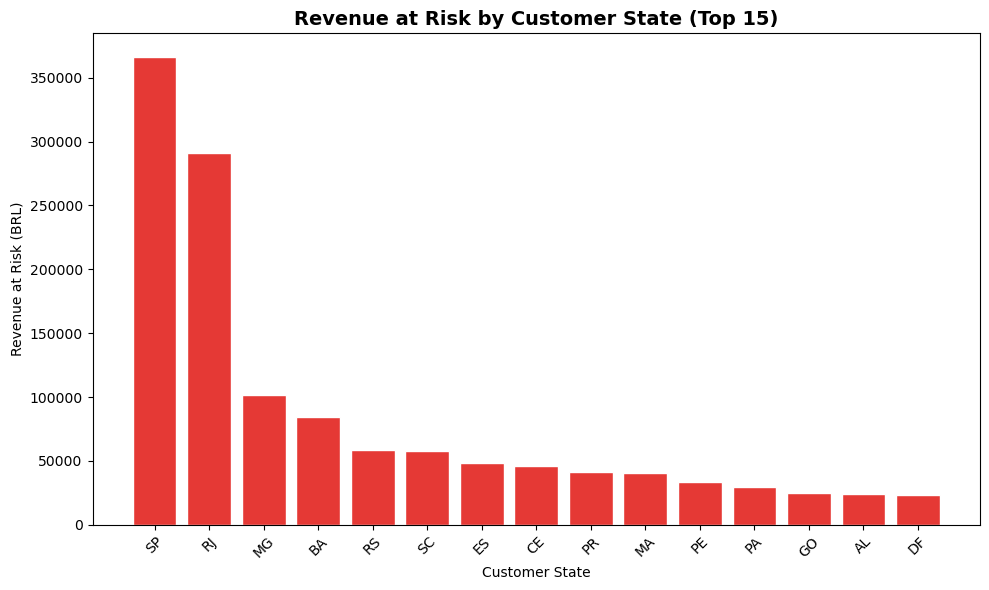

  ✅ Chart saved: 06_revenue_at_risk_by_state.png


In [ ]:
# Cell 14 — Chart 5: Revenue at risk by state
revenue_by_state = run_query(f"""
    SELECT
        customer_state,
        ROUND(SUM(revenue_at_risk), 2)      AS revenue_at_risk,
        COUNT(DISTINCT order_id)            AS total_orders,
        ROUND(AVG(is_late) * 100, 2)        AS late_pct
    FROM {TABLE}
    WHERE customer_state IS NOT NULL
    GROUP BY customer_state
    ORDER BY revenue_at_risk DESC
    LIMIT 15
""")

plt.figure(figsize=(10, 6))
bars = plt.bar(
    revenue_by_state["customer_state"],
    revenue_by_state["revenue_at_risk"],
    color="#E53935", edgecolor="white"
)
plt.title("Revenue at Risk by Customer State (Top 15)", fontsize=14, fontweight="bold")
plt.xlabel("Customer State")
plt.ylabel("Revenue at Risk (BRL)")
plt.xticks(rotation=45)
plt.tight_layout()
save_chart("06_revenue_at_risk_by_state.png")

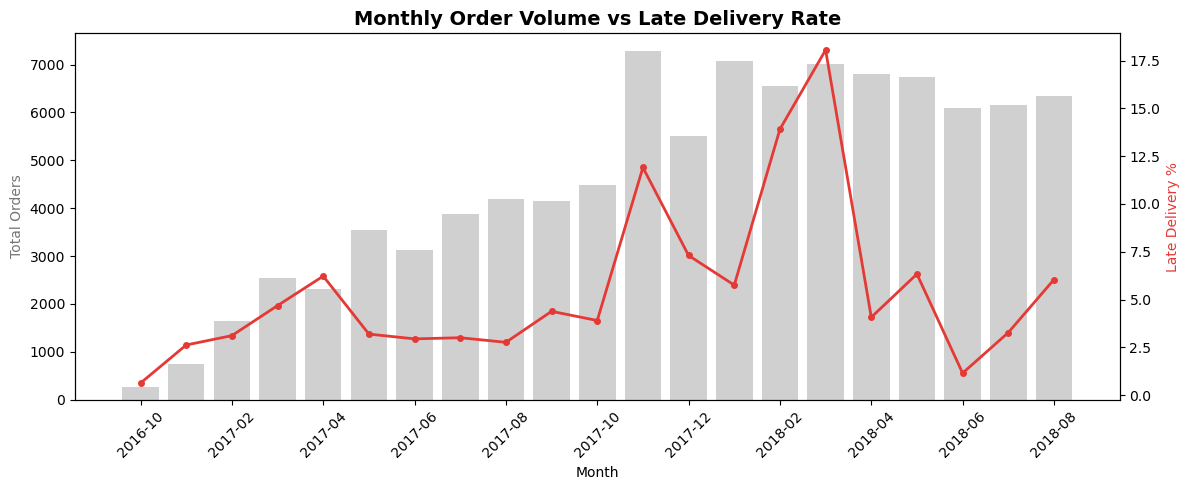

  ✅ Chart saved: 07_monthly_trend.png


In [ ]:
# Cell 15 — Chart 6: Monthly late % trend
monthly = run_query(f"""
    SELECT
        order_month,
        COUNT(DISTINCT order_id)            AS total_orders,
        ROUND(AVG(is_late) * 100, 2)        AS late_pct,
        ROUND(SUM(revenue_at_risk), 2)      AS revenue_at_risk
    FROM {TABLE}
    WHERE order_month IS NOT NULL
      AND delivery_delay_days IS NOT NULL
    GROUP BY order_month
    HAVING total_orders >= 50
    ORDER BY order_month ASC
""")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(monthly["order_month"], monthly["total_orders"],
        color="#BDBDBD", alpha=0.7, label="Total Orders")
ax2.plot(monthly["order_month"], monthly["late_pct"],
         color="#E53935", linewidth=2, marker="o", markersize=4, label="Late %")

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Orders", color="#757575")
ax2.set_ylabel("Late Delivery %", color="#E53935")
plt.title("Monthly Order Volume vs Late Delivery Rate", fontsize=14, fontweight="bold")

tick_step = max(1, len(monthly) // 10)
ax1.set_xticks(range(0, len(monthly), tick_step))
ax1.set_xticklabels(monthly["order_month"].iloc[::tick_step], rotation=45)

plt.tight_layout()
save_chart("07_monthly_trend.png")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


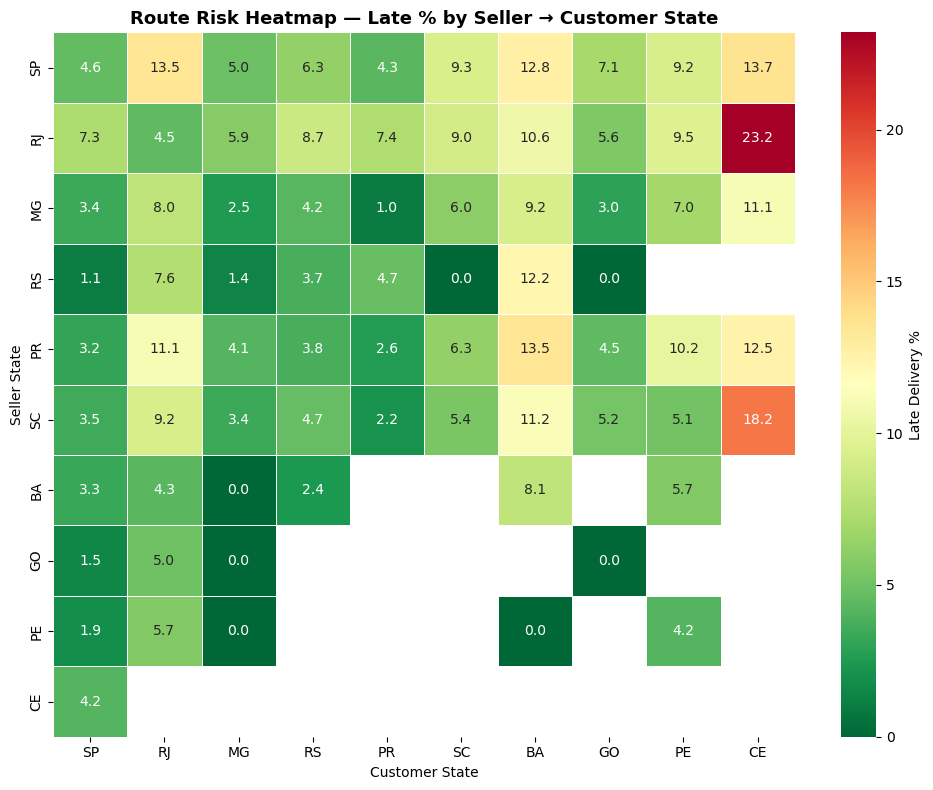

  ✅ Chart saved: 02_route_risk_heatmap.png


In [ ]:
# Cell 16 — Chart 7: Route risk heatmap (top states)
top_states = ["SP", "RJ", "MG", "RS", "PR", "SC", "BA", "GO", "PE", "CE"]

heatmap_data = run_query(f"""
    SELECT
        seller_state,
        customer_state,
        ROUND(AVG(is_late) * 100, 2) AS late_pct
    FROM {TABLE}
    WHERE seller_state   IN ('SP','RJ','MG','RS','PR','SC','BA','GO','PE','CE')
      AND customer_state IN ('SP','RJ','MG','RS','PR','SC','BA','GO','PE','CE')
      AND delivery_delay_days IS NOT NULL
    GROUP BY seller_state, customer_state
    HAVING COUNT(DISTINCT order_id) >= 20
""")

pivot = heatmap_data.pivot(
    index="seller_state", columns="customer_state", values="late_pct"
).reindex(index=top_states, columns=top_states)

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
    linewidths=0.5, cbar_kws={"label": "Late Delivery %"}
)
plt.title("Route Risk Heatmap — Late % by Seller → Customer State",
          fontsize=13, fontweight="bold")
plt.xlabel("Customer State")
plt.ylabel("Seller State")
plt.tight_layout()
save_chart("02_route_risk_heatmap.png")

Only 1 High Risk seller found:
  Seller ID    : b1b3948701c5c72445495bd161b83a4c
  State        : SP
  Late Rate    : 64.29%
  Avg Delay    : 4.07 days
  Revenue Risk : R$ 18,307.86
  Reliability  : 59.71


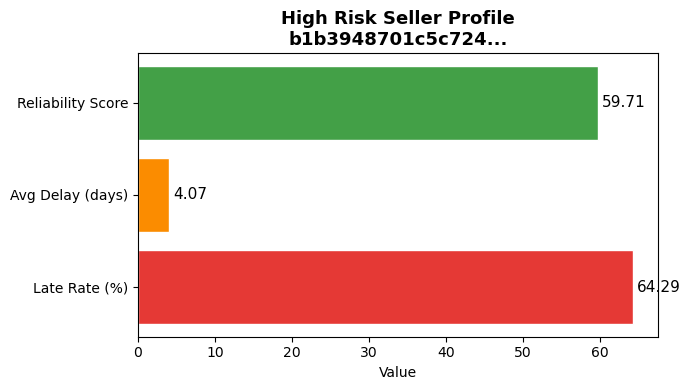

  ✅ Chart saved: 05_high_risk_sellers.png


In [ ]:
# Cell 17 — Chart 8: High risk sellers
high_risk = seller_scorecard[
    seller_scorecard["reliability_tier"] == "High Risk"
].nlargest(15, "total_revenue_at_risk")

if len(high_risk) == 0:
    print("No High Risk sellers found — skipping chart")

elif len(high_risk) == 1:
    # Single seller — show a summary text instead of a bar chart
    row = high_risk.iloc[0]
    print("Only 1 High Risk seller found:")
    print(f"  Seller ID    : {row['seller_id']}")
    print(f"  State        : {row['seller_state']}")
    print(f"  Late Rate    : {row['late_rate']}%")
    print(f"  Avg Delay    : {row['avg_delay_days']} days")
    print(f"  Revenue Risk : R$ {row['total_revenue_at_risk']:,.2f}")
    print(f"  Reliability  : {row['reliability_score']}")

    # Still save a readable chart
    fig, ax = plt.subplots(figsize=(7, 4))
    metrics = ["Late Rate (%)", "Avg Delay (days)", "Reliability Score"]
    values  = [row["late_rate"], row["avg_delay_days"], row["reliability_score"]]
    colors  = ["#E53935", "#FB8C00", "#43A047"]

    bars = ax.barh(metrics, values, color=colors, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val}", va="center", fontsize=11)

    ax.set_title(f"High Risk Seller Profile\n{row['seller_id'][:16]}...",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Value")
    plt.tight_layout()
    save_chart("05_high_risk_sellers.png")

else:
    plt.figure(figsize=(10, 6))
    plt.bar(
        range(len(high_risk)),
        high_risk["total_revenue_at_risk"],
        color="#E53935", edgecolor="white"
    )
    plt.xticks(range(len(high_risk)),
               [s[:8] + "..." for s in high_risk["seller_id"]],
               rotation=45, ha="right")
    plt.title("High Risk Sellers — Revenue at Risk", fontsize=14, fontweight="bold")
    plt.xlabel("Seller ID")
    plt.ylabel("Revenue at Risk (BRL)")
    plt.tight_layout()
    save_chart("05_high_risk_sellers.png")

In [ ]:
# Cell 18 — Final summary
print("=" * 60)
print("04_risk_intelligence.ipynb — COMPLETE")
print("=" * 60)

print(f"\n📊 Charts saved to data/charts/:")
charts = [
    "01_sla_distribution.png",
    "02_route_risk_heatmap.png",
    "03_top_routes.png",
    "04_seller_reliability.png",
    "05_high_risk_sellers.png",
    "06_revenue_at_risk_by_state.png",
    "07_monthly_trend.png",
    "08_demand_concentration.png",
]
for c in charts:
    print(f"   {c}")

print(f"\n📌 Key Findings:")
late_orders = sla_summary[sla_summary["sla_severity"] > 2]["order_count"].sum()
critical_routes = route_risk[route_risk["risk_tier"].isin(["Critical", "High"])].shape[0]
high_risk_sellers = seller_scorecard[seller_scorecard["reliability_tier"] == "High Risk"].shape[0]
auc_score = 0.7491  # from 03_ml_models

print(f"   • {late_orders:,} late orders across 3 severity tiers")
print(f"   • {critical_routes} high/critical risk routes identified")
print(f"   • {high_risk_sellers} high-risk sellers flagged")
print(f"   • ROC-AUC {auc_score} — model correctly ranks late order risk")

print(f"\n📁 BigQuery tables created:")
bq_tables = [
    "seller_scorecard", "sla_analysis", "sla_summary",
    "route_risk", "priority_orders", "demand_concentration"
]
for t in bq_tables:
    print(f"   {DATASET_ID}.{t}")

print(f"\nNext → run 05_dashboard_prep.ipynb")

04_risk_intelligence.ipynb — COMPLETE

📊 Charts saved to data/charts/:
   01_sla_distribution.png
   02_route_risk_heatmap.png
   03_top_routes.png
   04_seller_reliability.png
   05_high_risk_sellers.png
   06_revenue_at_risk_by_state.png
   07_monthly_trend.png
   08_demand_concentration.png

📌 Key Findings:
   • 7,264 late orders across 3 severity tiers
   • 3 high/critical risk routes identified
   • 1 high-risk sellers flagged
   • ROC-AUC 0.7491 — model correctly ranks late order risk

📁 BigQuery tables created:
   olist.seller_scorecard
   olist.sla_analysis
   olist.sla_summary
   olist.route_risk
   olist.priority_orders
   olist.demand_concentration

Next → run 05_dashboard_prep.ipynb
